## Diffeomorphic Bases Radial

Here, we do the diffeomorphic pullback operator on radial domains which are supposedly more stable:

In [4]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)


Visualize the vector field:



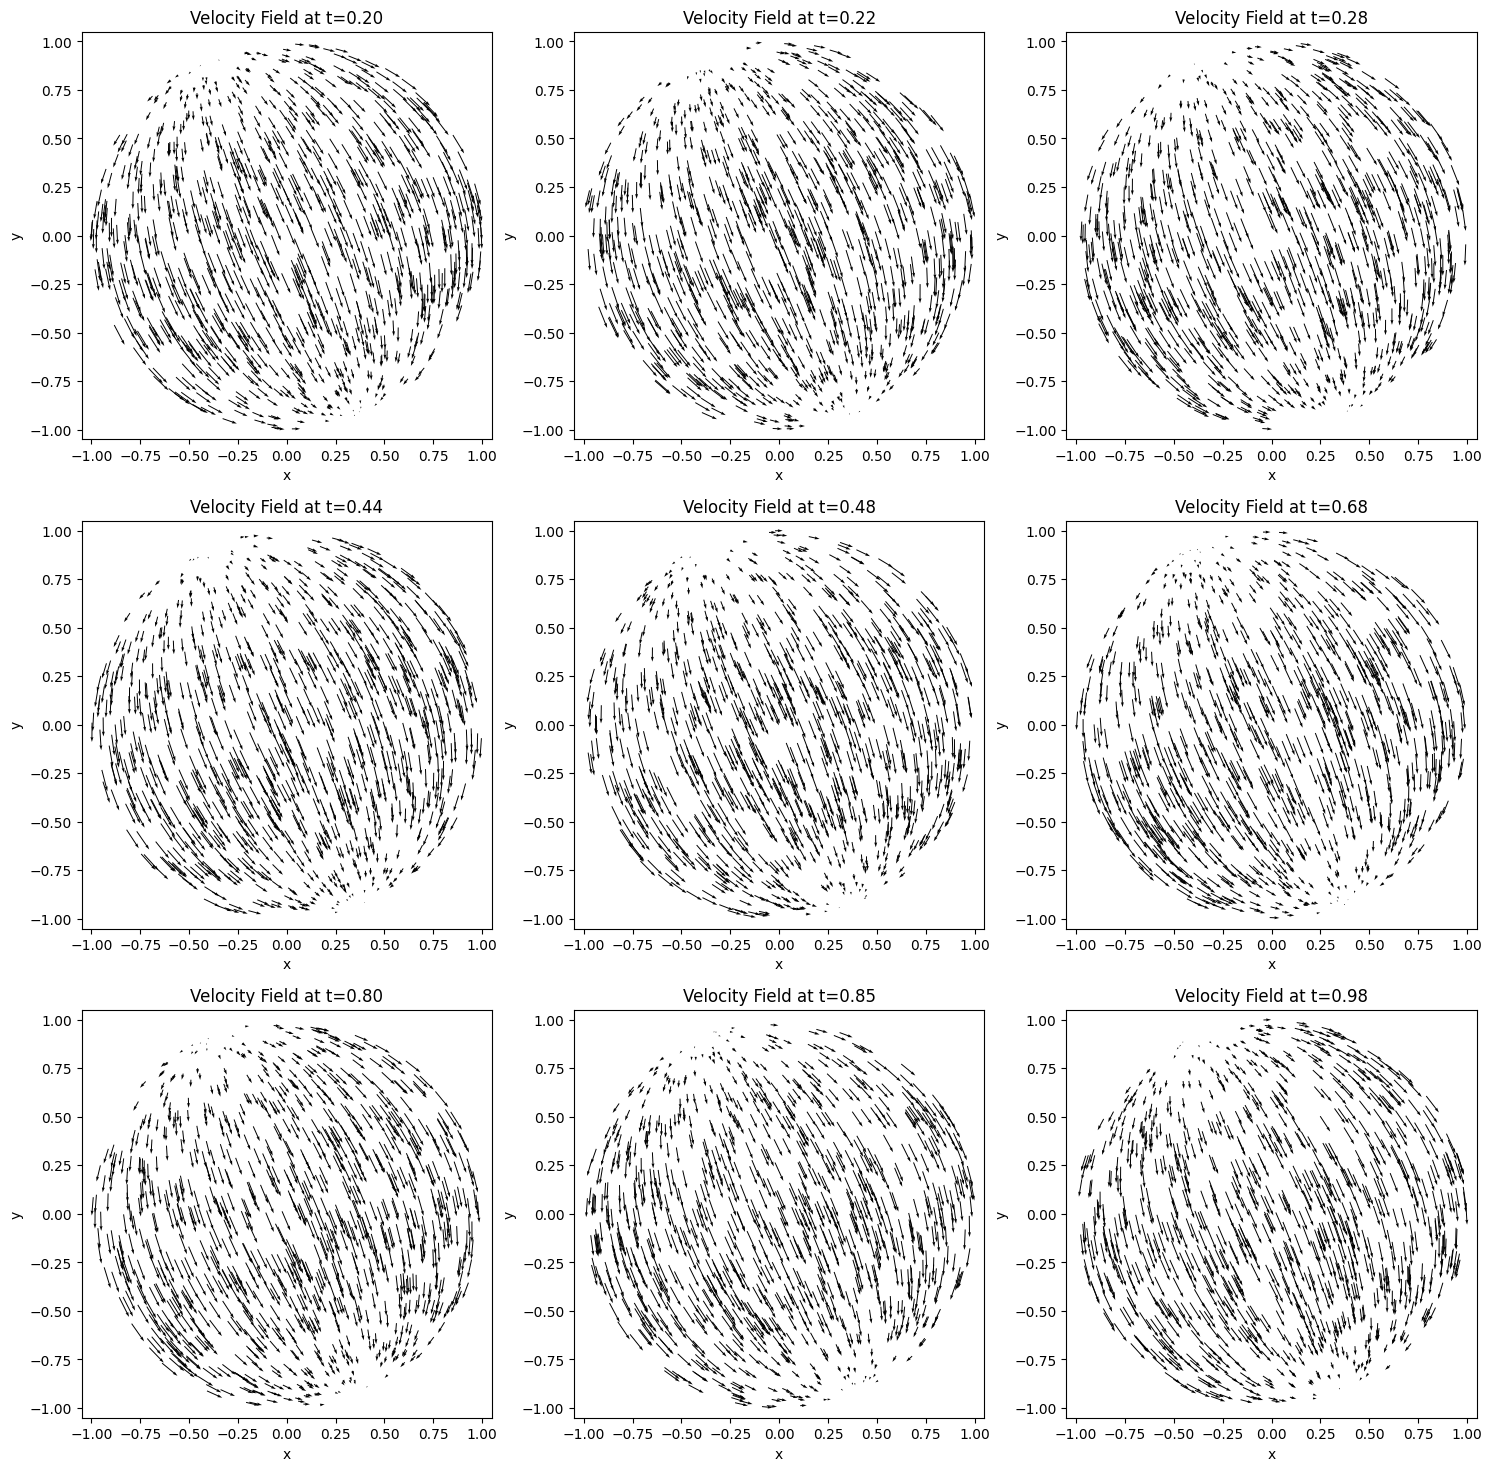

In [28]:
%autoreload 2
from half_densities.diffeomorphisms.continuous_time import CTRadialFlow
from half_densities.utils import polar_to_cartesian, sample_uniform_disk

torch.manual_seed(0)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
N = 1000
T = CTRadialFlow(
    dimensions=2,
    gamma = 1.,
    # normalize_velocity=True,
).to(device)
viz_magnitude = 10.0

rtheta = sample_uniform_disk(9 * N).to(device)
xy = polar_to_cartesian(rtheta)  # shape (9*N, 2)

# sample 9 random times in [0,1]
t = torch.rand(9).to(device)
# sort t for better visualization
t, _ = torch.sort(t)
# repeat t for each point
t = torch.repeat_interleave(t, N)
v =  viz_magnitude * T.velocity_field(t, xy)
# transform v to cartesian coordinates


for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = row * 3 + col
        ax.quiver(xy[idx * N:(idx + 1) * N,0].detach().cpu(), xy[idx * N:(idx + 1) * N,1].detach().cpu(),
                  v[idx * N:(idx + 1) * N,0].detach().cpu(), v[idx * N:(idx + 1) * N,1].detach().cpu(),
                  angles='xy', scale_units='xy', scale=10.0, alpha=1)
        ax.set_title(f'Velocity Field at t={t[idx * N].item():.2f}')
        ax.set_xlim(-1.05,1.05)
        ax.set_ylim(-1.05,1.05)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

Apply the pullback operator:

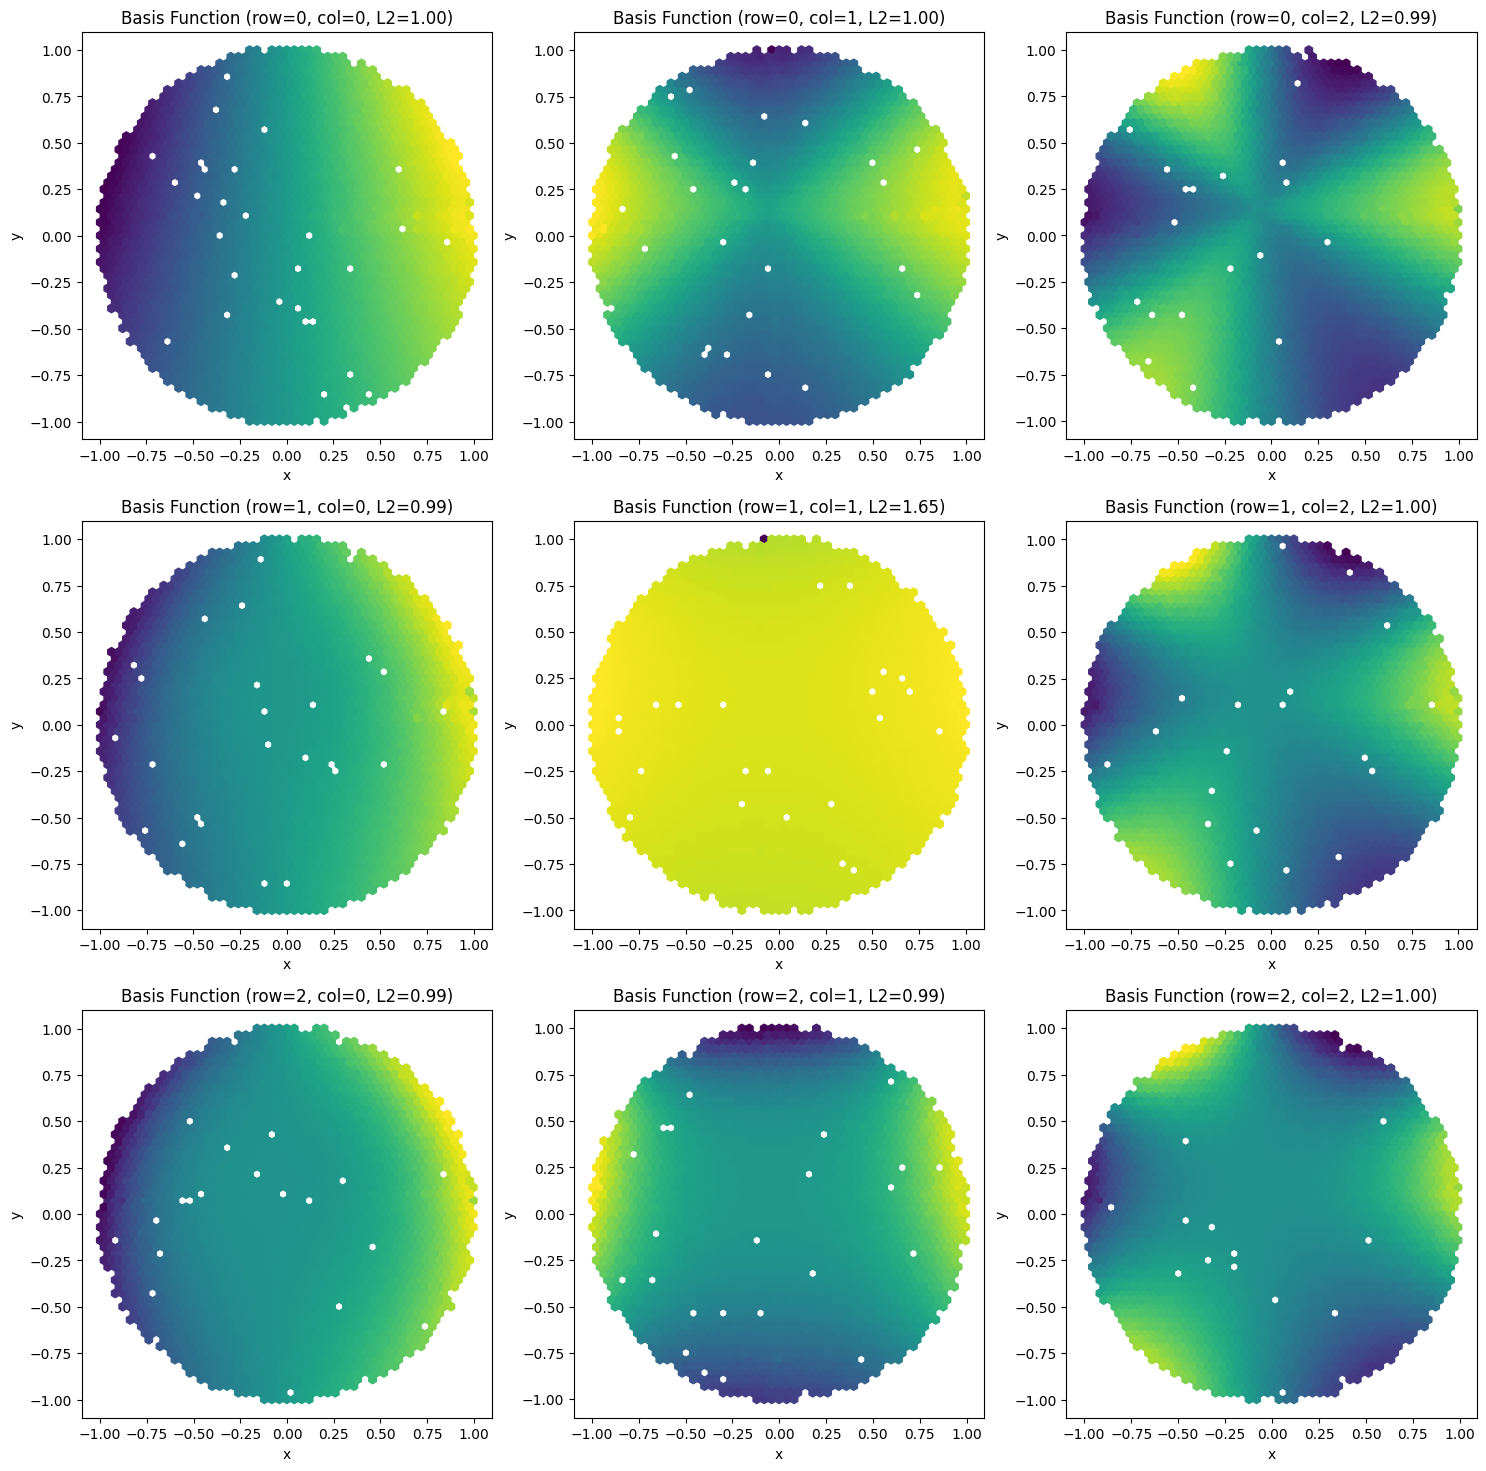

In [38]:
%autoreload 2
from half_densities.utils import radial_basis, polar_to_cartesian, sample_uniform_disk
import functools

# seed everything for reproducibility
torch.manual_seed(0)
N = 1000
end_time = 1.5
all_deformed_vals = []
all_original_vals = []
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        basis_func = functools.partial(radial_basis, n=row+1, m=col+1, indicator=0)
        N = 1000_0
        rtheta = sample_uniform_disk(N).to(device)
        xy = polar_to_cartesian(rtheta)
        all_original_vals.append(
            basis_func(xy).detach().cpu().numpy()
        )
        deformed_vals = T.evaluate(
            xy,
            start_time=0.0,
            end_time=end_time,
            initial_basis_fn=basis_func,
            n_steps=1000,
        )
        all_deformed_vals.append(deformed_vals.detach().cpu().numpy())
        # approximate integral by monte carlo
        integr = torch.sqrt((deformed_vals * deformed_vals).mean()).item()  # should be close to zero
        ax.hexbin(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), C=deformed_vals.detach().cpu(), gridsize=50, cmap='viridis') 
        ax.set_title(f'Basis Function (row={row}, col={col}, L2={integr:.2f})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

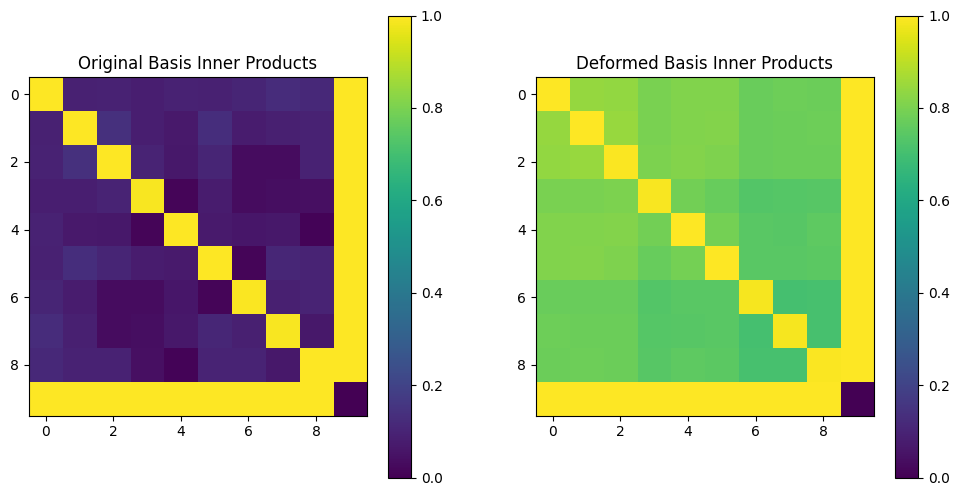

In [39]:
inner_products_defomed = np.zeros((9, 9))
inner_products_original = np.zeros((9, 9))
for i in range(len(all_deformed_vals)):
    for j in range(len(all_deformed_vals)):
        inner_products_defomed[i, j] = np.sqrt(np.abs(all_deformed_vals[i] * all_deformed_vals[j]).mean())
        inner_products_original[i, j] = np.sqrt(np.abs((all_original_vals[i] * all_original_vals[j]).mean()))

# clamp inner products between 0 and 1
inner_products_original = np.clip(inner_products_original, 0.0, 1.0)
inner_products_defomed = np.clip(inner_products_defomed, 0.0, 1.0)
# add a row with all zeros and a column with all ones
inner_products_original = np.pad(inner_products_original, ((0,1),(0,1)), mode='constant', constant_values=0)
inner_products_defomed = np.pad(inner_products_defomed, ((0,1),(0,1)), mode='constant', constant_values=0)
inner_products_original[-1, :-1] = 1.0
inner_products_original[:-1, -1] = 1.0
inner_products_defomed[-1, :-1] = 1.0
inner_products_defomed[:-1, -1] = 1.0

# plot two heatmaps side by side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
im0 = axes[0].imshow(inner_products_original, cmap='viridis')
axes[0].set_title('Original Basis Inner Products')
fig.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(inner_products_defomed, cmap='viridis')
axes[1].set_title('Deformed Basis Inner Products')
# set the minimum of the colorbar to 0
fig.colorbar(im1, ax=axes[1])
plt.show()

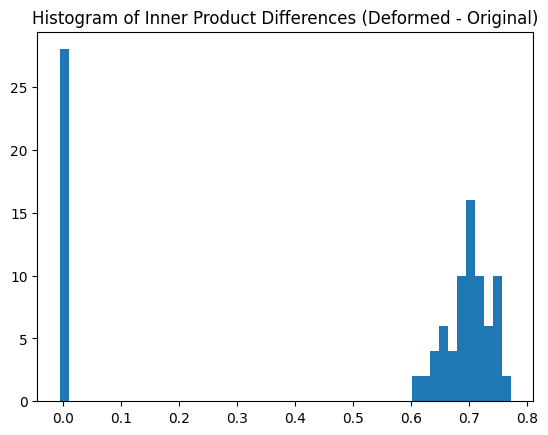

In [40]:
plt.hist(inner_products_defomed.flatten() - inner_products_original.flatten(), bins=50)
plt.title('Histogram of Inner Product Differences (Deformed - Original)')
plt.show()